## Module_3: *(Template)*

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*



## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*



### Import Packages

In [1]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

### Open Selected Images
Below are the 6 images we chose to analyze from the complete set of phots we were given

In [2]:
filenames = [
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010018.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010022.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
]

### Gather Data

The code below counts the pixels in each image for the specified depth

In [3]:
# Depths (microns)
depths = [15, 30, 45, 55, 60, 80]

white_counts = []
black_counts = []
white_percents = []

print(colored("Counts of pixels by color in each image", "yellow"))

for filename, depth in zip(filenames, depths):

    # Load image in grayscale
    img = cv2.imread(filename, 0)

    # Binary threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Pixel counts
    white = np.count_nonzero(binary)
    total = binary.size
    black = total - white

    # Percent white
    white_percent = 100 * white / total

    # Store values
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)

    # Print results
    print(colored(f"{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "blue"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n")

# Save results to CSV
df = pd.DataFrame({
    "Filename": filenames,
    "Depth (microns)": depths,
    "White Percent": white_percents
})

df.to_csv("Percent_White_Pixels.csv", index=False)

print("CSV file 'Percent_White_Pixels.csv' created.")



Counts of pixels by color in each image
C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg:
White pixels: 27561
Black pixels: 4166743
0.66% White | Depth: 15 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010018.jpg:
White pixels: 33746
Black pixels: 4160558
0.80% White | Depth: 30 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg:
White pixels: 31331
Black pixels: 4162973
0.75% White | Depth: 45 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 55 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010022.jpg:
White pixels: 33151
Black pixels: 4161153
0.79% White | Depth: 60 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg:
Whi

### Linear Interpolation:
Because the minimum depth is 15 and the max is 80, the value to interpolate must be between these two.

Using points: (45, 0.7469892501831055) and (55, 0.5698204040527344)
A = [ 1.54424906 -0.01771688]
At depth 50.0, estimated % white = 0.658


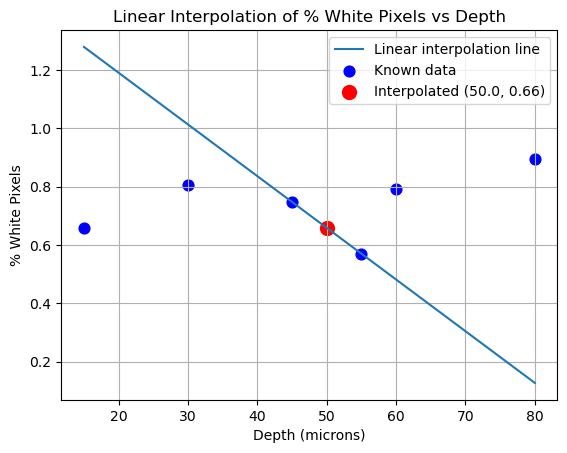

In [ ]:

# Load CSV
df = pd.read_csv("Percent_White_Pixels.csv")

# Extract columns
depths = df["Depth (microns)"].tolist()
white_percents = df["White Percent"].tolist()

# Ask user for interpolation depth
interp_depth = float(input("Enter depth to interpolate (microns): "))

# Convert to numpy for indexing
depths_np = np.array(depths)

# Find insertion index
idx = np.searchsorted(depths_np, interp_depth)

# Safety check: must be between two known points
if idx == 0 or idx == len(depths):
    raise ValueError("Interpolation depth must be inside the range of your data.")

# Select the two points for linear interpolation
x1, x2 = depths[idx - 1], depths[idx]
y1, y2 = white_percents[idx - 1], white_percents[idx]
print(f"Using points: ({x1}, {y1}) and ({x2}, {y2})")


# BUILD Z AND Y MATRICES
Z = np.array([[1, x1], [1, x2]])
Y = np.array([y1, y2])

# SOLVE FOR A
A = np.linalg.solve(Z, Y)
a1, a2 = A
print("A =", A)


# COMPUTE INTERPOLATED VALUE
interp_value = a1 + a2 * interp_depth
print(f"At depth {interp_depth}, estimated % white = {interp_value:.3f}")


# PLOT RESULTS
# Line for visualization
x_line = np.linspace(min(depths), max(depths), 200)
y_line = a1 + a2 * x_line

plt.plot(x_line, y_line, label="Linear interpolation line")
plt.scatter(depths, white_percents, color='blue', s=60, label='Known data')
plt.scatter(interp_depth, interp_value, color='red', s=100,
            label=f'Interpolated ({interp_depth}, {interp_value:.2f})')

plt.title("Linear Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Quadratic Interpolation

Because the minimum depth is 15 and the max is 80, the value to interpolate must be between these two.


Using points: (45, 0.7469892501831055), (55, 0.5698204040527344), (60, 0.7903814315795898)
A = [ 1.17460489e+01 -4.29910819e-01  4.12193934e-03]
At depth 50.0, estimated % white = 0.555


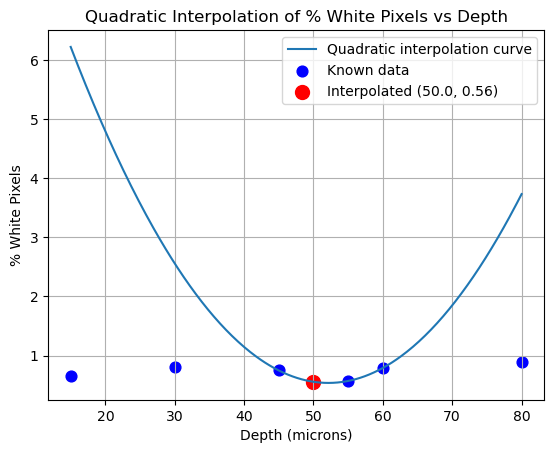

In [ ]:
# Load CSV
df = pd.read_csv("Percent_White_Pixels.csv")

# Extract columns
depths = df["Depth (microns)"].tolist()
white_percents = df["White Percent"].tolist()

# Ask user for interpolation depth
interp_depth = float(input("Enter depth to interpolate (microns): "))

# Convert to numpy for indexing
depths_np = np.array(depths)

# Find insertion index
idx = np.searchsorted(depths_np, interp_depth)

# Safety check: need one point below and two above OR two below and one above
if idx < 1 or idx > len(depths) - 2:
    raise ValueError("Quadratic interpolation requires the depth to be strictly inside the data range.")

# Select three points for quadratic interpolation
x1, x2, x3 = depths[idx - 1], depths[idx], depths[idx + 1]
y1, y2, y3 = white_percents[idx - 1], white_percents[idx], white_percents[idx + 1]

print(f"Using points: ({x1}, {y1}), ({x2}, {y2}), ({x3}, {y3})")


# BUILD Z AND Y MATRICES
Z = np.array([[1, x1, x1**2], [1, x2, x2**2], [1, x3, x3**2]])
Y = np.array([y1, y2, y3])


# SOLVE FOR A
A = np.linalg.solve(Z, Y)
a1, a2, a3 = A
print("A =", A)


# COMPUTE INTERPOLATED VALUE
interp_value = a1 + a2 * interp_depth + a3 * interp_depth**2
print(f"At depth {interp_depth}, estimated % white = {interp_value:.3f}")


# PLOT RESULTS
x_line = np.linspace(min(depths), max(depths), 300)
y_line = a1 + a2 * x_line + a3 * x_line**2

plt.plot(x_line, y_line, label="Quadratic interpolation curve")
plt.scatter(depths, white_percents, color='blue', s=60, label='Known data')
plt.scatter(interp_depth, interp_value, color='red', s=100,
            label=f'Interpolated ({interp_depth}, {interp_value:.2f})')

plt.title("Quadratic Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Third Degree Interpolation (Polynomial)

Using points:
(45, 0.7469892501831055)
(55, 0.5698204040527344)
(60, 0.7903814315795898)
(80, 0.8942604064941406)
A = [ 3.58398329e+01 -1.80496010e+00  3.00815719e-02 -1.62247703e-04]
At depth 50.0, estimated % white = 0.515


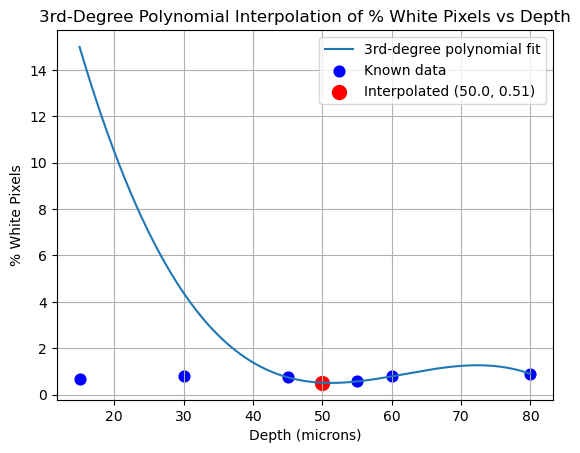

In [13]:
# Load CSV
df = pd.read_csv("Percent_White_Pixels.csv")

# Extract columns
depths = df["Depth (microns)"].tolist()
white_percents = df["White Percent"].tolist()

# Ask user for interpolation depth
interp_depth = float(input("Enter depth to interpolate (microns): "))

# Convert to numpy for indexing
depths_np = np.array(depths)

# Degree 3 → need 4 points
degree = 3
num_points = degree + 1

# Find insertion index
idx = np.searchsorted(depths_np, interp_depth)

# Safety check: need 1 point below and 2 above OR 2 below and 1 above
if idx < 1 or idx > len(depths) - 3:
    raise ValueError("3rd-degree interpolation requires the depth to be well inside the data range.")

# Select 4 surrounding points
start = idx - 1
end = start + num_points

x_points = depths[start:end]
y_points = white_percents[start:end]

print("Using points:")
for x, y in zip(x_points, y_points):
    print(f"({x}, {y})")


# BUILD Z MATRIX (Vandermonde)
Z = np.zeros((num_points, num_points))
for i in range(num_points):
    for j in range(num_points):
        Z[i, j] = x_points[i] ** j
Y = np.array(y_points)


# SOLVE FOR A
A = np.linalg.solve(Z, Y)
print("A =", A)


# COMPUTE INTERPOLATED VALUE
interp_value = sum(A[j] * interp_depth**j for j in range(num_points))
print(f"At depth {interp_depth}, estimated % white = {interp_value:.3f}")


# PLOT RESULTS
x_line = np.linspace(min(depths), max(depths), 400)
y_line = np.zeros_like(x_line)

for j in range(num_points):
    y_line += A[j] * x_line**j

plt.plot(x_line, y_line, label="3rd-degree polynomial fit")
plt.scatter(depths, white_percents, color='blue', s=60, label='Known data')
plt.scatter(interp_depth, interp_value, color='red', s=100,
            label=f'Interpolated ({interp_depth}, {interp_value:.2f})')

plt.title("3rd-Degree Polynomial Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Fourth Degree Interpolation (Polynomial)

Using points:
(30, 0.8045673370361328)
(45, 0.7469892501831055)
(55, 0.5698204040527344)
(60, 0.7903814315795898)
(80, 0.8942604064941406)
A = [-3.97526409e+01  3.45406174e+00 -1.05291314e-01  1.36487298e-03
 -6.36300284e-06]
At depth 50.0, estimated % white = 0.563


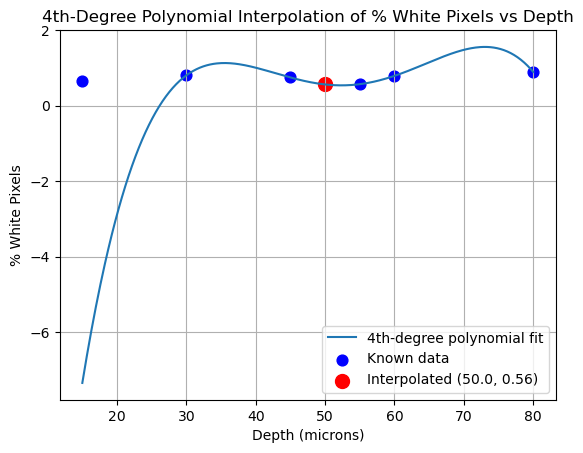

In [14]:
# Load CSV
df = pd.read_csv("Percent_White_Pixels.csv")

# Extract columns
depths = df["Depth (microns)"].tolist()
white_percents = df["White Percent"].tolist()

# Ask user for interpolation depth
interp_depth = float(input("Enter depth to interpolate (microns): "))

# Convert to numpy for indexing
depths_np = np.array(depths)

# Degree 4 → need 5 points
degree = 4
num_points = degree + 1

# Find insertion index
idx = np.searchsorted(depths_np, interp_depth)

# Safety check: need 2 points below and 2 above
if idx < 2 or idx > len(depths) - 3:
    raise ValueError("4th-degree interpolation requires the depth to be well inside the data range.")

# Select 5 surrounding points
start = idx - 2
end = start + num_points

x_points = depths[start:end]
y_points = white_percents[start:end]

print("Using points:")
for x, y in zip(x_points, y_points):
    print(f"({x}, {y})")


# BUILD Z MATRIX (Vandermonde)
Z = np.zeros((num_points, num_points))

for i in range(num_points):
    for j in range(num_points):
        Z[i, j] = x_points[i] ** j
Y = np.array(y_points)


# SOLVE FOR A
A = np.linalg.solve(Z, Y)
print("A =", A)


# COMPUTE INTERPOLATED VALUE
interp_value = sum(A[j] * interp_depth**j for j in range(num_points))
print(f"At depth {interp_depth}, estimated % white = {interp_value:.3f}")


# PLOT RESULTS
x_line = np.linspace(min(depths), max(depths), 400)
y_line = np.zeros_like(x_line)

for j in range(num_points):
    y_line += A[j] * x_line**j

plt.plot(x_line, y_line, label="4th-degree polynomial fit")
plt.scatter(depths, white_percents, color='blue', s=60, label='Known data')
plt.scatter(interp_depth, interp_value, color='red', s=100,
            label=f'Interpolated ({interp_depth}, {interp_value:.2f})')

plt.title("4th-Degree Polynomial Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("% White Pixels")
plt.grid(True)
plt.legend()
plt.show()

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*